# Differential Expression: Autophagy-Targeted

In this notebook, I run pseudobulk differential expression on the current broad-class annotation workflow and then focus the output on a curated autophagy and mitochondrial gene panel. The workflow is intentionally broad-class only: `Excitatory`, `Inhibitory`, `Glia`, and `Vascular`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT


## 1. Load The Broad-Class Pseudobulk Source Object

I load the full-gene pseudobulk source object prepared in notebook 10. This object contains the raw-count matrix together with the current broad Harmony labels.


In [3]:
RESULTS_DIR = PROJECT_ROOT / "results"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
FIGURES_DIR = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, DE_BROAD_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

adata_merged_pb = sc.read_h5ad(PROJECT_ROOT / "data/processed/merged/adata_merged_pb.h5ad")

print(adata_merged_pb.shape)
print("Has counts:", "counts" in adata_merged_pb.layers)
print("Has cell_class_major_harmony:", "cell_class_major_harmony" in adata_merged_pb.obs.columns)
print(adata_merged_pb.obs["cell_class_major_harmony"].value_counts(dropna=False))


(88883, 61552)
Has counts: True
Has cell_class_major_harmony: True
cell_class_major_harmony
Glia          65529
Excitatory    16001
Inhibitory     6717
Vascular        636
Name: count, dtype: int64


In [4]:
broad_main_classes = [
    label for label in ["Excitatory", "Inhibitory", "Glia", "Vascular"]
    if label in set(adata_merged_pb.obs["cell_class_major_harmony"].dropna().astype(str))
]

pairwise_tests = [
    ("Control", "sALS"),
    ("Control", "c9ALS"),
    ("sALS", "c9ALS"),
]

autophagy_genes = [
    # C9/autophagy core
    "C9orf72", "SMCR8", "WDR41",
    "ULK1", "ULK2", "RB1CC1", "ATG13", "ATG101",
    "BECN1", "PIK3C3", "ATG14", "WIPI2",
    "ATG5", "ATG7", "ATG12", "ATG16L1",
    "MAP1LC3B", "GABARAPL1", "GABARAPL2",
    "SQSTM1", "OPTN", "CALCOCO2", "TAX1BP1", "NBR1",
    "TBK1", "LAMP1", "LAMP2", "RAB7A", "CTSD",
    # canonical mitophagy
    "PINK1", "PRKN", "BNIP3", "BNIP3L", "FUNDC1",
    "PHB2", "BCL2L13", "FKBP8",
    # mitochondria dynamics: fission / fusion
    "DNM1L", "FIS1", "MFF", "MIEF1", "MIEF2",
    "MFN1", "MFN2", "OPA1",
    # mitochondrial transport / membrane / contact / turnover relevance
    "RHOT1", "RHOT2", "VDAC1", "TOMM20", "TOMM70",
    "TIMM23", "TIMM44",
    # mitochondrial proteostasis / UPRmt / stress response
    "LONP1", "CLPP", "CLPX", "AFG3L2", "SPG7",
    "HSPD1", "HSPE1", "DNAJA3",
    # mitochondrial biogenesis / transcriptional control
    "PPARGC1A", "PPARGC1B", "NRF1", "NRF2", "TFAM",
    "TFB1M", "TFB2M", "POLG", "POLG2",
    # respiration / mitochondrial function / homeostasis
    "NDUFS1", "NDUFV1", "SDHA", "UQCRC1", "COX4I1", "ATP5F1A",
    "SOD2", "PRDX3", "GPX4", "TXN2",
    # mitochondrial membrane potential / calcium / permeability transition
    "IMMT", "MICOS10", "MCU", "MICU1", "MICU2",
    "SLC25A4", "SLC25A5",
    # lysosome / acidification / autophagosome-lysosome axis
    "ATP6V1A", "ATP6V0C", "RAB9A", "UVRAG", "VPS11", "VPS16"
]

print("Broad classes analysed:", broad_main_classes)


Broad classes analysed: ['Excitatory', 'Inhibitory', 'Glia', 'Vascular']


## 1B. Check Donor Pseudobulk Retention Per Broad Class

Before running DE, I check how many donor-level pseudobulk samples are actually retained in each broad class after applying the minimum cell threshold. This is the key sample-size diagnostic for interpreting downstream DE results.

In [8]:
MIN_CELLS_PER_SAMPLE = 20

retention_rows = []
retention_tables = {}

for group_name in broad_main_classes:
    sub = adata_merged_pb[
        adata_merged_pb.obs["cell_class_major_harmony"].astype(str) == str(group_name)
    ].copy()

    if sub.n_obs == 0:
        print(f"\n===== {group_name} =====")
        print("No cells found for this group.")
        continue

    donor_counts = (
        sub.obs
        .groupby(["condition", "sample"])
        .size()
        .reset_index(name="n_cells")
    )

    donor_counts["retained"] = donor_counts["n_cells"] >= MIN_CELLS_PER_SAMPLE
    retention_tables[group_name] = donor_counts.copy()

    summary = (
        donor_counts
        .groupby("condition")
        .agg(
            n_donors_total=("sample", "nunique"),
            n_donors_retained=("retained", "sum"),
            min_cells=("n_cells", "min"),
            median_cells=("n_cells", "median"),
            max_cells=("n_cells", "max"),
        )
        .reset_index()
    )

    summary["group_name"] = group_name
    retention_rows.append(summary)

    print(f"\n===== {group_name} =====")
    print("Per-donor cell counts and retention:")
    display(donor_counts.sort_values(["condition", "sample"]))

    print("Condition-level retention summary:")
    display(summary)

retention_summary_df = pd.concat(retention_rows, ignore_index=True)

print("\nCombined retention summary across broad classes:")
display(
    retention_summary_df[
        ["group_name", "condition", "n_donors_total", "n_donors_retained", "min_cells", "median_cells", "max_cells"]
    ].sort_values(["group_name", "condition"])
)



===== Excitatory =====
Per-donor cell counts and retention:


,condition,sample,n_cells,retained
0,Control,GSM5292143,0,False
1,Control,GSM5292144,0,False
2,Control,GSM5292145,0,False
3,Control,GSM5292146,0,False
4,Control,GSM5292147,0,False
5,Control,GSM5292148,0,False
6,Control,GSM5292156,0,False
7,Control,GSM5292157,0,False
8,Control,GSM5292174,749,True
9,Control,GSM5292175,756,True


Condition-level retention summary:


,condition,n_donors_total,n_donors_retained,min_cells,median_cells,max_cells,group_name
0,Control,12,4,0,0.0,847,Excitatory
1,c9ALS,12,4,0,0.0,2844,Excitatory
2,sALS,12,4,0,0.0,2092,Excitatory



===== Inhibitory =====
Per-donor cell counts and retention:


...

,condition,sample,n_cells,retained
0,Control,GSM5292143,0,False
1,Control,GSM5292144,0,False
2,Control,GSM5292145,0,False
3,Control,GSM5292146,0,False
4,Control,GSM5292147,0,False
5,Control,GSM5292148,0,False
6,Control,GSM5292156,0,False
7,Control,GSM5292157,0,False
8,Control,GSM5292174,30,True
9,Control,GSM5292175,64,True


Condition-level retention summary:


,condition,n_donors_total,n_donors_retained,min_cells,median_cells,max_cells,group_name
0,Control,12,3,0,0.0,64,Vascular
1,c9ALS,12,4,0,0.0,77,Vascular
2,sALS,12,3,0,0.0,115,Vascular



Combined retention summary across broad classes:


,group_name,condition,n_donors_total,n_donors_retained,min_cells,median_cells,max_cells
0,Excitatory,Control,12,4,0,0.0,847
1,Excitatory,c9ALS,12,4,0,0.0,2844
2,Excitatory,sALS,12,4,0,0.0,2092
6,Glia,Control,12,4,0,0.0,5228
7,Glia,c9ALS,12,4,0,0.0,5918
8,Glia,sALS,12,4,0,0.0,10175
3,Inhibitory,Control,12,4,0,0.0,409
4,Inhibitory,c9ALS,12,4,0,0.0,1410
5,Inhibitory,sALS,12,4,0,0.0,1067
9,Vascular,Control,12,3,0,0.0,64


## 2. Define Pseudobulk And DE Helper Functions

I aggregate raw counts at donor level within each broad class, then run pairwise DESeq2 comparisons between conditions. I round pseudobulk counts to integers before fitting DESeq2, which is appropriate for count-based modelling.


In [5]:
def pseudobulk_by_sample(
    adata,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
):
    sub = adata[adata.obs[groupby_col].astype(str) == str(group_value)].copy()
    if sub.n_obs == 0:
        raise ValueError(f"No cells found for {groupby_col}={group_value!r}.")

    cell_counts = sub.obs["sample"].astype(str).value_counts()
    keep_samples = cell_counts[cell_counts >= min_cells_per_sample].index.tolist()
    if not keep_samples:
        raise ValueError(
            f"No samples retained for {groupby_col}={group_value!r} "
            f"with min_cells_per_sample={min_cells_per_sample}."
        )

    sub = sub[sub.obs["sample"].astype(str).isin(keep_samples)].copy()
    sample_order = sorted(sub.obs["sample"].astype(str).unique())

    pb_counts = []
    pb_meta = []

    for samp in sample_order:
        ss = sub[sub.obs["sample"].astype(str) == samp]
        x = ss.layers[layer] if layer in ss.layers else ss.X
        if hasattr(x, "toarray"):
            x = x.toarray()

        pb_counts.append(np.asarray(x.sum(axis=0)).ravel())
        pb_meta.append({
            "sample": samp,
            "condition": ss.obs["condition"].astype(str).iloc[0],
            "group_value": str(group_value),
            "groupby_col": groupby_col,
            "n_cells": ss.n_obs,
        })

    counts_df = pd.DataFrame(pb_counts, index=sample_order, columns=sub.var_names)
    meta_df = pd.DataFrame(pb_meta).set_index("sample")
    return counts_df, meta_df


def run_pairwise_deseq(counts_df, meta_df, group_a, group_b):
    keep = meta_df["condition"].isin([group_a, group_b])
    counts_use = counts_df.loc[keep].copy()
    meta_use = meta_df.loc[keep].copy()

    counts_use = counts_use.round().astype(int)

    dds = DeseqDataSet(
        counts=counts_use,
        metadata=meta_use,
        design="~condition",
        refit_cooks=True,
    )
    dds.deseq2()

    stats = DeseqStats(dds, contrast=["condition", group_b, group_a])
    summary_res = stats.summary()

    if isinstance(summary_res, pd.DataFrame):
        res = summary_res.copy()
    elif hasattr(stats, "results_df"):
        res = stats.results_df.copy()
    else:
        result_attrs = [attr for attr in dir(stats) if "result" in attr.lower()]
        raise AttributeError(
            "Could not retrieve DESeq2 results from DeseqStats. "
            f"Available result-like attributes: {result_attrs}"
        )

    res["gene"] = res.index
    return res


## 3. Run Broad-Class Autophagy-Targeted Differential Expression

For each broad class, I run pairwise condition comparisons, then save only the subset of results corresponding to the targeted autophagy and mitochondrial gene panel.


In [6]:
broad_de_results = {}
skipped_groups = []

for ct in broad_main_classes:
    try:
        counts_df, meta_df = pseudobulk_by_sample(
            adata_merged_pb,
            group_value=ct,
            groupby_col="cell_class_major_harmony",
            min_cells_per_sample=20,
            layer="counts",
        )
    except ValueError as e:
        skipped_groups.append((ct, str(e)))
        print(f"Skipping {ct}: {e}")
        continue

    for g1, g2 in pairwise_tests:
        res = run_pairwise_deseq(counts_df, meta_df, g1, g2)
        res_panel = res[res["gene"].isin(autophagy_genes)].copy()
        res_panel.to_csv(DE_BROAD_DIR / f"{ct}_{g1}_vs_{g2}_mito_qc.csv", index=False)
        broad_de_results[(ct, g1, g2)] = res_panel

print("Skipped groups:", skipped_groups)


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.03 seconds.

Fitting dispersion trend curve...
... done in 0.42 seconds.

Fitting MAP dispersions...
... done in 2.70 seconds.

Fitting LFCs...
... done in 2.29 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.39 seconds.



Log2 fold change & Wald test p-value: condition sALS vs Control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4            6.828566       -1.585594  0.613716 -2.583597  0.009778   
TNFRSF18          26.313478       -1.203909  0.480687 -2.504559  0.012260   
ATAD3B           282.685516       -0.490433  0.208421 -2.353084  0.018618   
ENSG00000260179    1.396937       -0.715959  1.329215 -0.538633  0.590140   
ENSG00000234396   23.076513       -0.506040  0.371845 -1.360887  0.173549   
...                     ...             ...       ...       ...       ...   
ENSG00000271254   66.519207        0.520868  0.276199  1.885841  0.059316   
U1-4               0.123835        1.447701  3.843067  0.376705  0.706393   
ENSG00000268674    0.075409       -0.392627  3.893686 -0.100837  0.919680   
ENSG00000277475    0.106132       -0.392627  3.893686 -0.100837  0.919680   
U1-5               1.207777        0.567850  1.464149  0.387836  0.698137   

           

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.14 seconds.

Fitting dispersion trend curve...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 2.76 seconds.

Fitting LFCs...
... done in 2.11 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.39 seconds.



Log2 fold change & Wald test p-value: condition c9ALS vs Control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4           19.175522        0.581364  0.505417  1.150266  0.250034   
TNFRSF18          42.261174       -1.046802  0.412623 -2.536944  0.011182   
ATAD3B           431.618092       -0.444524  0.200614 -2.215818  0.026704   
ENSG00000260179    1.545217       -2.929131  1.596253 -1.835004  0.066505   
ENSG00000234396   38.120461       -0.179600  0.299956 -0.598755  0.549336   
...                     ...             ...       ...       ...       ...   
ENSG00000271254   71.051580       -0.507526  0.318133 -1.595328  0.110639   
U1-4               0.114587       -0.113172  3.872200 -0.029227  0.976684   
ENSG00000268674    0.199330       -0.834513  3.726243 -0.223956  0.822792   
ENSG00000277475    0.161097       -1.555856  3.872657 -0.401754  0.687865   
U1-5               1.586952        0.572780  1.462515  0.391641  0.695324   

          

...

Fitting dispersions...
... done in 0.92 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 1.61 seconds.

Fitting LFCs...
... done in 1.35 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.55 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value: condition c9ALS vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4          0.417511        1.626207  2.787322  0.583430  0.559604   
TNFRSF18         0.098498        0.652166  3.263988  0.199806  0.841632   
ATAD3B           1.532555        0.141462  1.266950  0.111656  0.911096   
ENSG00000260179  0.000000             NaN       NaN       NaN       NaN   
ENSG00000234396  0.000000             NaN       NaN       NaN       NaN   
...                   ...             ...       ...       ...       ...   
ENSG00000271254  0.915554        0.343745  1.712229  0.200759  0.840887   
U1-4             0.000000             NaN       NaN       NaN       NaN   
ENSG00000268674  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277475  0.000000             NaN       NaN       NaN       NaN   
U1-5             0.000000             NaN       NaN       NaN       NaN   

                     padj  
TNFRSF

Fitting dispersions...
... done in 1.29 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 1.35 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition c9ALS vs sALS
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
TNFRSF4          0.587894        2.872745  3.211255  0.894586  0.371008   NaN
TNFRSF18         0.226639        0.774092  3.709324  0.208688  0.834692   NaN
ATAD3B           2.228314        0.028008  1.077079  0.026004  0.979255   NaN
ENSG00000260179  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000234396  0.087633        0.049347  4.118481  0.011982  0.990440   NaN
...                   ...             ...       ...       ...       ...   ...
ENSG00000271254  1.018921        1.084902  2.089742  0.519156  0.603652   NaN
U1-4             0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000268674  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000277475  0.000000             NaN       NaN       NaN       NaN   NaN
U1-5             0.000000             NaN       NaN       NaN       NaN   NaN

[

... done in 1.43 seconds.



## 4. Define Broad-Class Visualisation And Summary Helpers

I keep a small set of functions to inspect pseudobulk results at gene level and across the targeted panel.


In [7]:
def format_comparison_for_display(comparison):
    g1, g2 = comparison.split("_vs_")
    return f"{g2} vs {g1}"


def load_de_result(group_name, comparison, suffix="_mito_qc.csv"):
    fn = DE_BROAD_DIR / f"{group_name}_{comparison}{suffix}"
    if not fn.exists():
        raise FileNotFoundError(f"Result file not found: {fn}")
    df = pd.read_csv(fn)
    df["group_name"] = group_name
    df["comparison"] = comparison
    return df


def plot_volcano(group_name, comparison, genes_to_label=None, padj_cutoff=0.1, lfc_cutoff=0.5):
    df = load_de_result(group_name, comparison).dropna(subset=["padj", "log2FoldChange"]).copy()
    df["neglog10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))
    df["sig"] = "NS"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] > lfc_cutoff), "sig"] = "Up"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] < -lfc_cutoff), "sig"] = "Down"

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"NS": "lightgray", "Up": "firebrick", "Down": "steelblue"}
    for label in ["NS", "Up", "Down"]:
        sub = df[df["sig"] == label]
        ax.scatter(sub["log2FoldChange"], sub["neglog10_padj"], s=28, alpha=0.8, color=colors[label], label=label)

    if genes_to_label:
        label_df = df[df["gene"].isin(genes_to_label)].copy()
        for _, row in label_df.iterrows():
            ax.text(row["log2FoldChange"], row["neglog10_padj"], row["gene"], fontsize=8)

    ax.axvline(lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axvline(-lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axhline(-np.log10(padj_cutoff), linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(f"{group_name} | {format_comparison_for_display(comparison)}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df


def plot_log2fc_heatmap(group_names, comparisons, genes, ytick_fontsize=8):
    long_dfs = []
    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(group_name, comparison).dropna(subset=["padj", "log2FoldChange"]).copy()
            df["row"] = f"{group_name} | {format_comparison_for_display(comparison)}"
            long_dfs.append(df[["gene", "row", "log2FoldChange"]])

    long_df = pd.concat(long_dfs, ignore_index=True)
    long_df = long_df[long_df["gene"].isin(genes)].copy()
    mat = long_df.pivot_table(index="gene", columns="row", values="log2FoldChange", fill_value=0)
    mat = mat.loc[[g for g in genes if g in mat.index]]

    vmax = np.nanmax(np.abs(mat.values)) if mat.size else 1
    fig_h = max(8, 0.28 * max(len(mat.index), 1))
    fig, ax = plt.subplots(figsize=(14, fig_h))
    im = ax.imshow(mat.values, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=ytick_fontsize)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_title("log2FC heatmap | broad classes")
    plt.colorbar(im, ax=ax, label="log2 fold change")
    plt.tight_layout()
    plt.show()
    return mat


def summarize_gene(gene, group_names, comparisons):
    rows = []
    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(group_name, comparison)
            df["comparison"] = format_comparison_for_display(comparison)
            hit = df[df["gene"] == gene].copy()
            if not hit.empty:
                rows.append(hit)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    keep_cols = [c for c in ["group_name", "comparison", "gene", "log2FoldChange", "padj", "pvalue", "baseMean"] if c in out.columns]
    return out[keep_cols].sort_values(["group_name", "comparison"]).reset_index(drop=True)


def plot_gene_by_condition(
    adata,
    gene,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
    normalisation="CPM",
    figsize=(6, 5),
):
    counts_df, meta_df = pseudobulk_by_sample(
        adata,
        group_value=group_value,
        groupby_col=groupby_col,
        min_cells_per_sample=min_cells_per_sample,
        layer=layer,
    )

    if gene not in counts_df.columns:
        raise ValueError(f"{gene} not found in pseudobulk counts.")

    plot_df = meta_df.copy()

    if normalisation.upper() == "CPM":
        libsize = counts_df.sum(axis=1)
        expr = np.log1p(counts_df.div(libsize, axis=0) * 1e6)
        ylab = f"log1p(CPM) of {gene}"
        plot_df["expr"] = expr[gene]
    else:
        plot_df["expr"] = np.log1p(counts_df[gene])
        ylab = f"log1p(raw pseudobulk count) of {gene}"

    cond_order = ["Control", "sALS", "c9ALS"]
    x_pos = {cond: i for i, cond in enumerate(cond_order)}

    fig, ax = plt.subplots(figsize=figsize)

    for cond in cond_order:
        sub = plot_df[plot_df["condition"] == cond].copy()
        if sub.empty:
            continue

        jitter = np.linspace(-0.08, 0.08, len(sub)) if len(sub) > 1 else np.array([0.0])
        xs = np.full(len(sub), x_pos[cond]) + jitter

        ax.scatter(xs, sub["expr"], s=50, alpha=0.9, label=cond)

        for x, (_, row) in zip(xs, sub.iterrows()):
            ax.text(x, row["expr"], row.name, fontsize=7, alpha=0.8)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(cond_order)
    ax.set_ylabel(ylab)
    ax.set_title(f"{gene} in {group_value}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return plot_df


## 5. Example Broad-Class Visualisations

These example calls inspect the current broad-class targeted results. I use `Glia` here because the older microglia-specific branch has been intentionally removed from the workflow.


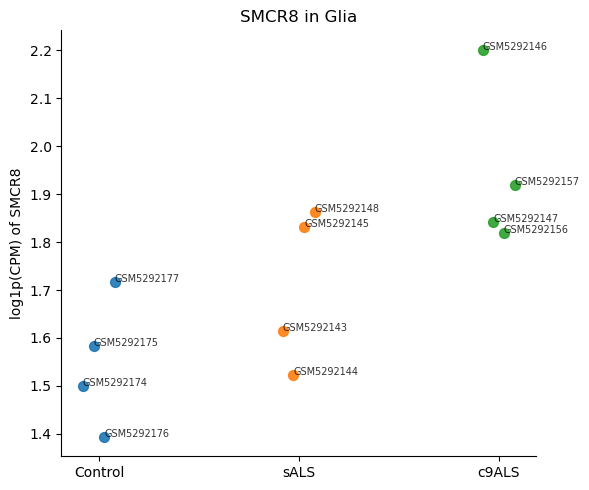

,condition,group_value,groupby_col,n_cells,expr
sample,,,,,
GSM5292143,sALS,Glia,cell_class_major_harmony,5284,1.614439
GSM5292144,sALS,Glia,cell_class_major_harmony,10175,1.523032
GSM5292145,sALS,Glia,cell_class_major_harmony,4883,1.831910
GSM5292146,c9ALS,Glia,cell_class_major_harmony,5434,2.201626
GSM5292147,c9ALS,Glia,cell_class_major_harmony,5918,1.843022
GSM5292148,sALS,Glia,cell_class_major_harmony,8041,1.862283
GSM5292156,c9ALS,Glia,cell_class_major_harmony,4309,1.819003
GSM5292157,c9ALS,Glia,cell_class_major_harmony,4369,1.919022
GSM5292174,Control,Glia,cell_class_major_harmony,4811,1.499599


In [12]:
# Plot one gene's donor-level pseudobulk expression across conditions within a chosen broad class.
plot_gene_by_condition(  
    adata_merged_pb,     # Full-gene pseudobulk source AnnData object.
    gene="SMCR8",        # Gene to plot; must exist in adata_merged_pb.var_names.
    group_value="Glia",  # "Excitatory", "Inhibitory", "Glia", "Vascular".
    groupby_col="cell_class_major_harmony",  # obs column used to define the groups; use "cell_class_major_harmony" in this workflow.
    min_cells_per_sample=20,  # Minimum cells required per donor within the group to retain that donor in the pseudobulk plot.
)

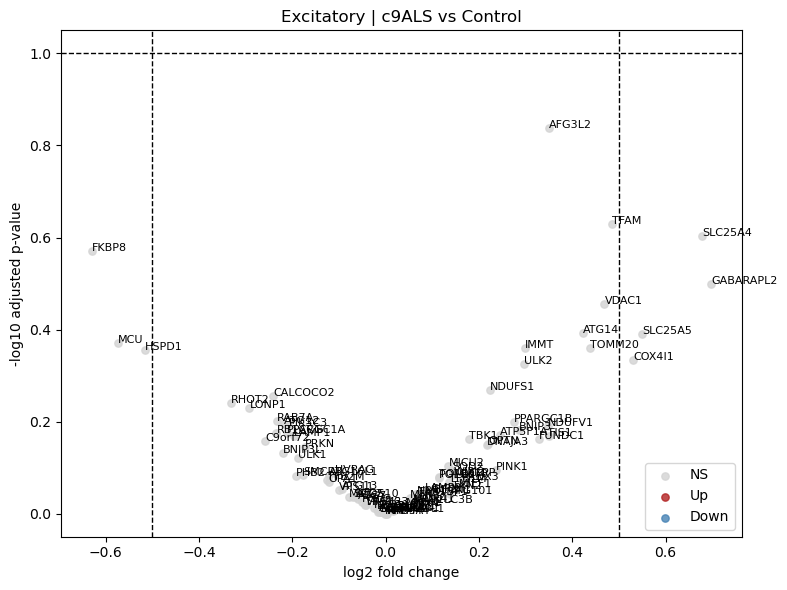

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,group_name,comparison,neglog10_padj,sig
0,184.502923,-0.078503,0.217933,-0.360217,0.718684,0.920779,MICOS10,Excitatory,Control_vs_c9ALS,0.035845,NS
1,264.953257,-0.124639,0.203123,-0.613613,0.539471,0.842387,TFB2M,Excitatory,Control_vs_c9ALS,0.074488,NS
2,3658.832738,0.437863,0.275980,1.586575,0.112609,0.436871,TOMM20,Excitatory,Control_vs_c9ALS,0.359647,NS
3,1190.756627,0.235832,0.324577,0.726582,0.467482,0.803721,PINK1,Excitatory,Control_vs_c9ALS,0.094895,NS
4,787.240541,0.057774,0.236086,0.244716,0.806676,0.949607,MFN2,Excitatory,Control_vs_c9ALS,0.022456,NS
...,...,...,...,...,...,...,...,...,...,...,...
86,577.729263,-0.291587,0.235853,-1.236305,0.216345,0.588969,LONP1,Excitatory,Control_vs_c9ALS,0.229907,NS
87,1504.442777,0.051728,0.305504,0.169321,0.865544,0.966589,GPX4,Excitatory,Control_vs_c9ALS,0.014758,NS
88,252.769314,0.156483,0.301150,0.519616,0.603331,0.874680,MIEF1,Excitatory,Control_vs_c9ALS,0.058151,NS
89,1530.373793,-0.019129,0.148289,-0.129001,0.897357,0.974186,BCL2L13,Excitatory,Control_vs_c9ALS,0.011358,NS


In [ ]:
# Make a volcano plot for one broad class and one pairwise condition comparison.
plot_volcano(  
    group_name="Excitatory",          # "Excitatory", "Inhibitory", "Glia", "Vascular".
    comparison="Control_vs_c9ALS",    # "Control_vs_sALS", "Control_vs_c9ALS", "sALS_vs_c9ALS".
    genes_to_label=autophagy_genes,   # Genes to label on the plot; use a list like autophagy_genes, a custom gene list, or None.
)

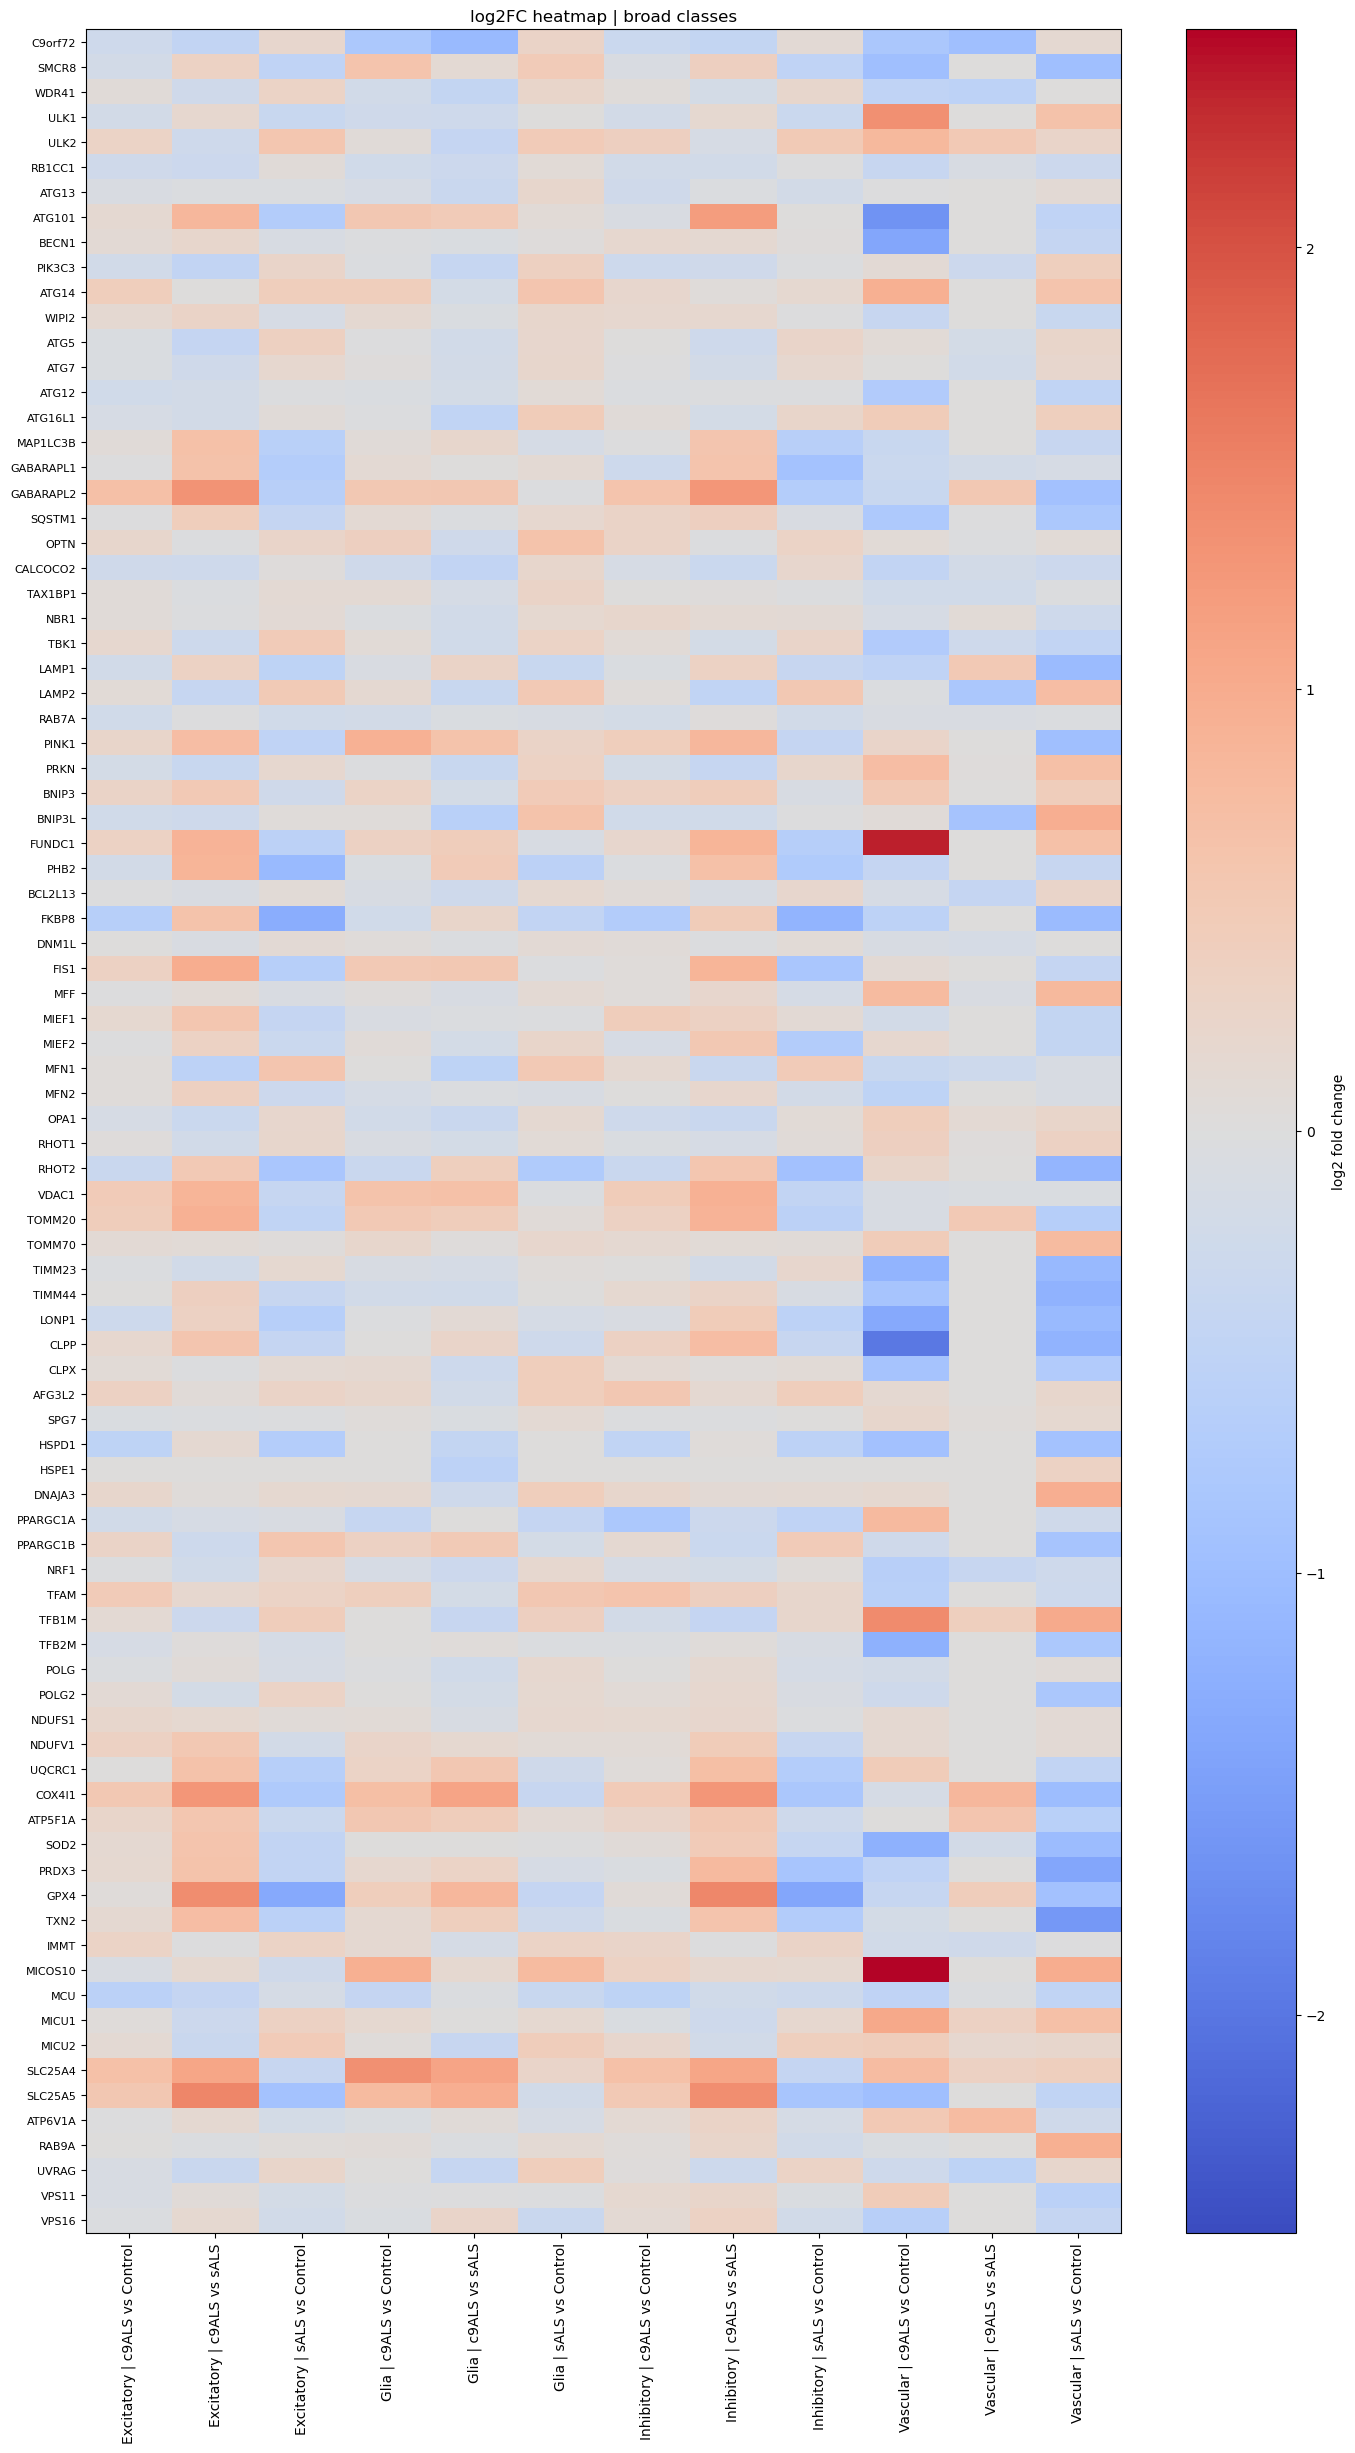

row,Excitatory | c9ALS vs Control,Excitatory | c9ALS vs sALS,Excitatory | sALS vs Control,Glia | c9ALS vs Control,Glia | c9ALS vs sALS,Glia | sALS vs Control,Inhibitory | c9ALS vs Control,Inhibitory | c9ALS vs sALS,Inhibitory | sALS vs Control,Vascular | c9ALS vs Control,Vascular | c9ALS vs sALS,Vascular | sALS vs Control
gene,,,,,,,,,,,,
C9orf72,-0.258452,-0.460071,0.203171,-0.786354,-1.060978,0.275538,-0.329464,-0.428612,0.103056,-0.802416,-0.958062,0.151228
SMCR8,-0.177036,0.317837,-0.493490,0.611251,0.126280,0.483541,-0.092085,0.387972,-0.494362,-0.961026,0.000000,-0.967438
WDR41,0.060617,-0.235066,0.300093,-0.204566,-0.443553,0.239016,0.050928,-0.170481,0.215173,-0.501826,-0.530676,0.015500
ULK1,-0.187325,0.182004,-0.366698,-0.247243,-0.256508,0.008997,-0.175389,0.156787,-0.328818,1.357303,0.000000,0.661048
ULK2,0.297408,-0.268289,0.571399,0.062879,-0.409951,0.473088,0.378602,-0.123471,0.505736,0.817674,0.512961,0.262074
...,...,...,...,...,...,...,...,...,...,...,...,...
ATP6V1A,-0.015173,0.152126,-0.161322,-0.061214,0.067124,-0.129521,0.129473,0.274526,-0.147078,0.517863,0.754909,-0.247972
RAB9A,0.001932,-0.039419,0.043944,0.065286,-0.058143,0.123538,0.040209,0.250021,-0.204077,-0.075711,0.000000,0.953815
UVRAG,-0.107417,-0.344972,0.242600,0.017130,-0.396730,0.416361,0.025528,-0.280020,0.307774,-0.259515,-0.522727,0.225686


In [14]:
plot_log2fc_heatmap(
    group_names=broad_main_classes,
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
    genes=autophagy_genes,
)

In [1]:
summarize_gene(
    gene="RB1CC1",
    group_names=broad_main_classes,
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
)

NameError: name 'summarize_gene' is not defined